# Análisis de tráfico web
Este cuaderno consulta los registros HTTP almacenados en PostgreSQL y genera estadísticas.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, URL, text

url = URL.create(
    'postgresql+psycopg',
    username=os.environ['POSTGRES_USER'],
    password=os.environ['POSTGRES_PASSWORD'],
    host='database',
    port=5432,
    database=os.environ['POSTGRES_DB']
)
engine = create_engine(url)
print('Conexión preparada')

Conexión preparada


In [2]:
consulta = '''
SELECT ts, client_ip, method, path, status, bytes_sent
FROM nginx_requests
ORDER BY ts DESC
LIMIT 1000
'''
with engine.connect() as conn:
    resultado = conn.execute(text(consulta))
    df = pd.DataFrame(resultado.fetchall(), columns=list(resultado.keys()))
print('Registros obtenidos:', len(df))
display(df.head(10))

Registros obtenidos: 1000


,ts,client_ip,method,path,status,bytes_sent
0,2026-10-03 15:32:22+00:00,172.19.0.1,GET,/jupyter/api/terminals?1791041542180,200,2
1,2026-10-03 15:32:21+00:00,172.19.0.1,GET,/jupyter/api/contents?content=1&1791041541759,200,476
2,2026-10-03 15:32:21+00:00,172.19.0.1,GET,/jupyter/api/contents?content=1&1791041541570,200,476
3,2026-10-03 15:32:21+00:00,172.19.0.1,GET,/jupyter/api/contents?content=1&1791041541134,200,476
4,2026-10-03 15:32:20+00:00,172.19.0.1,GET,/jupyter/api/contents?content=1&1791041540940,200,476
5,2026-10-03 15:32:20+00:00,172.19.0.1,GET,/jupyter/api/contents?content=1&1791041540688,200,476
6,2026-10-03 15:32:20+00:00,172.19.0.1,GET,/jupyter/api/contents?content=1&1791041540500,200,476
7,2026-10-03 15:32:20+00:00,172.19.0.1,GET,/jupyter/api/contents?content=1&1791041540216,200,476
8,2026-10-03 15:32:20+00:00,172.19.0.1,GET,/jupyter/api/contents?content=1&1791041540020,200,476
9,2026-10-03 15:32:20+00:00,172.19.0.1,GET,/jupyter/static/favicons/favicon-busy-1.ico,304,0


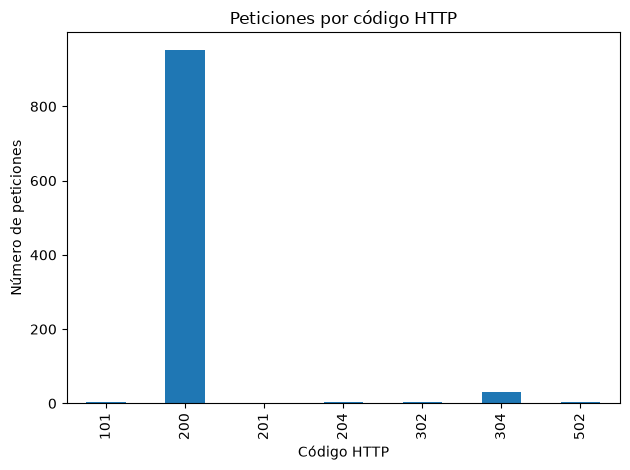

In [3]:
if not df.empty:
    df.groupby('status').size().sort_index().plot(kind='bar')
    plt.title('Peticiones por código HTTP')
    plt.xlabel('Código HTTP')
    plt.ylabel('Número de peticiones')
    plt.tight_layout()
    plt.show()
else:
    print('Todavía no hay peticiones registradas. Visita el portal y vuelve a ejecutar esta celda.')

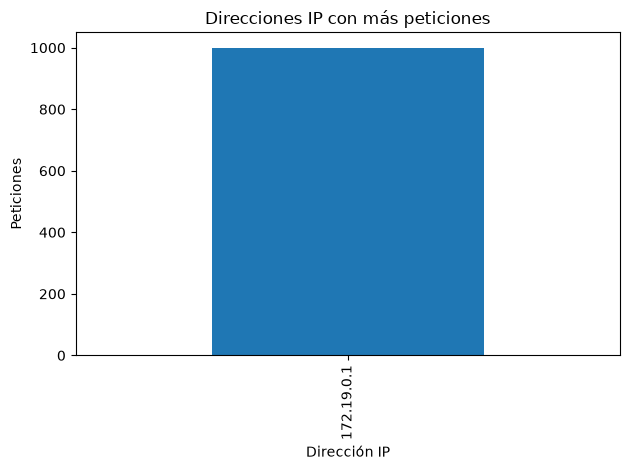

In [4]:
if not df.empty:
    df.groupby('client_ip').size().sort_values(ascending=False).head(10).plot(kind='bar')
    plt.title('Direcciones IP con más peticiones')
    plt.xlabel('Dirección IP')
    plt.ylabel('Peticiones')
    plt.tight_layout()
    plt.show()